# Sit. 2 — Colab: EDA + entrenamiento GeoVision-CLIP + SAE

1. Descarga `Slucu-0310/geovision-cali-sit2` desde Hugging Face.
2. **EDA exhaustivo** (tablas y gráficos para el informe).
3. **Entrenamiento** (solo train; validación/KPIs Recall@k en otro paso).

Dataset esperado: **1350** pares, tiles `(N, 13, 64, 64)` int16, split 70/15/15.

In [1]:
# @title Dependencias
%pip install -q huggingface_hub zarr numcodecs pandas pyarrow numpy matplotlib seaborn scipy
%pip install -q torch torchvision pytorch-lightning open-clip-torch transformers sentencepiece wandb tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


In [2]:
# @title Hugging Face — descarga dataset
import os
from pathlib import Path

HF_REPO_ID = "Slucu-0310/geovision-cali-sit2"
DATA_DIR = Path("/content/dataset_sit2")
EDA_DIR = Path("/content/eda_sit2")
RUN_DIR = Path("/content/runs/sit2_clip_colab")
EDA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
except Exception:
    pass

from huggingface_hub import login, snapshot_download

if os.environ.get("HF_TOKEN"):
    login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)

snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    local_dir=str(DATA_DIR),
    local_dir_use_symlinks=False,
)
print("Dataset en:", DATA_DIR)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

Dataset en: /content/dataset_sit2


In [3]:
# @title Utilidades de lectura (inline)
from __future__ import annotations
import json
from typing import Any, Literal
import numpy as np
import pandas as pd
import zarr

SEED = 42
CLASES = [
    "contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
    "vegetacion_densa", "suelo_urbano",
]
BANDAS_S2 = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12","SCL"]
_IDX_RGB = {"B4": 3, "B3": 2, "B2": 1}
SplitName = Literal["train", "val", "test"]
NUMERIC_COLS = [
    "valid_ratio", "frac_nubes_scl", "frac_claros_scl", "frac_nodata_scl",
    "ndvi", "bsi", "no2", "so2", "o3",
]

def _zarr_store(path: str):
    try:
        return zarr.storage.LocalStore(path)
    except AttributeError:
        return zarr.DirectoryStore(path)

def open_tiles_zarr(zarr_path):
    p = str(zarr_path)
    try:
        root = zarr.open(p, mode="r")
    except Exception:
        root = zarr.open(_zarr_store(p), mode="r")
    if isinstance(root, zarr.Array):
        return root
    if "tiles" in root:
        return root["tiles"]
    for _, a in root.arrays():
        return a
    raise ValueError(p)

def compute_band_stats(zarr_path, n_sample=512, seed=SEED):
    rng = np.random.default_rng(seed)
    arr = open_tiles_zarr(zarr_path)
    n = int(arr.shape[0])
    idx = rng.choice(n, size=min(n_sample, n), replace=False)
    sample = np.stack([np.asarray(arr[i], dtype=np.float32) for i in idx])
    mean = sample.mean(axis=(0, 2, 3))
    std = np.maximum(sample.std(axis=(0, 2, 3)), 1e-3)
    return mean.astype("float32"), std.astype("float32")

def tile_to_rgb_uint8(tile_13hw, p_low=2, p_high=98):
    chans = []
    for b in ("B4", "B3", "B2"):
        x = tile_13hw[_IDX_RGB[b]].astype(np.float32)
        fin = x[np.isfinite(x)]
        lo, hi = (np.percentile(fin, [p_low, p_high]) if fin.size else (0, 1))
        if hi <= lo:
            hi = lo + 1
        chans.append((np.clip((x - lo) / (hi - lo), 0, 1) * 255).astype(np.uint8))
    return np.stack(chans, axis=-1)

META_PATH = DATA_DIR / "metadatos.parquet"
ZARR_PATH = DATA_DIR / "tiles.zarr"
df = pd.read_parquet(META_PATH)
tiles_z = open_tiles_zarr(ZARR_PATH)
secuencias = json.loads((DATA_DIR / "secuencias.json").read_text(encoding="utf-8"))
resumen = json.loads((DATA_DIR / "resumen.json").read_text(encoding="utf-8"))
assert len(df) == int(tiles_z.shape[0])
print(f"Pares: {len(df)} | tiles: {tiles_z.shape}")


Pares: 1350 | tiles: (1350, 13, 64, 64)


## 1. EDA exhaustivo (informe)

Balance, estadísticas por clase, correlaciones y muestras visuales. Salidas en `EDA_DIR`.

=== Balance global ===
 clase
contaminacion_alta_NO2    270
contaminacion_alta_SO2    270
ozono_anomalo             270
vegetacion_densa          270
suelo_urbano              270
Name: n, dtype: int64

=== Balance por split ===
 clase  contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split                                                                  
test                       41                      40             41   
train                     189                     189            189   
val                        40                      41             40   

clase  suelo_urbano  vegetacion_densa  
split                                  
test             41                40  
train           189               189  
val              40                41  


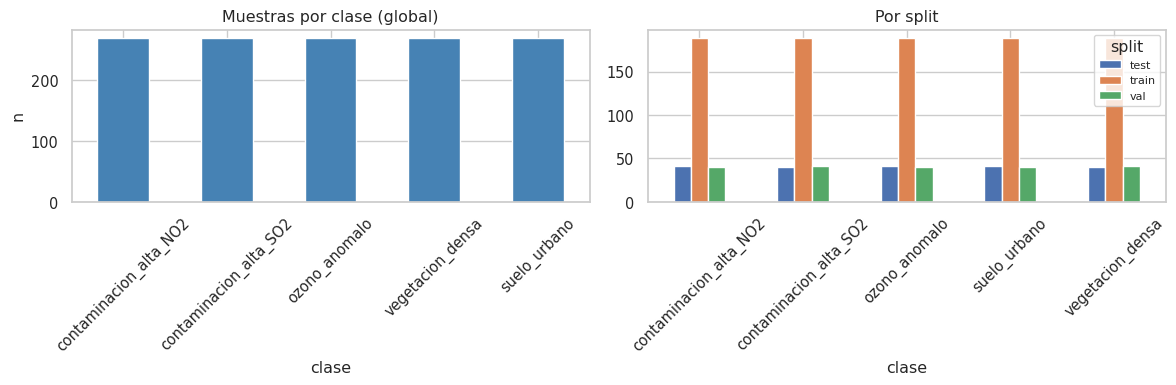


=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===


KeyError: 'ndvi'

In [4]:
# @title EDA — tablas y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
rng = np.random.default_rng(SEED)

# --- Balance global y por split ---
bal_global = df["clase"].value_counts().reindex(CLASES).rename("n")
bal_global.to_csv(EDA_DIR / "balance_global.csv")
print("=== Balance global ===\n", bal_global)

bal_split = df.groupby(["split", "clase"]).size().unstack(fill_value=0)
bal_split.to_csv(EDA_DIR / "balance_por_split.csv")
print("\n=== Balance por split ===\n", bal_split)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bal_global.plot(kind="bar", ax=axes[0], color="steelblue", rot=45)
axes[0].set_title("Muestras por clase (global)")
axes[0].set_ylabel("n")
bal_split.T.plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("Por split")
axes[1].legend(title="split", fontsize=8)
plt.tight_layout()
plt.savefig(EDA_DIR / "01_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Estadísticas numéricas por clase ---
stats = df.groupby("clase")[NUMERIC_COLS].agg(["mean", "std", "min", "max", "median"])
stats.to_csv(EDA_DIR / "estadisticas_por_clase.csv")
print("\n=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===")
print(stats.loc[:, pd.IndexSlice[:, ["ndvi", "bsi", "frac_nubes_scl", "no2", "so2", "o3"]]].round(6))

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(data=df, x="clase", y=col, ax=axes[i], order=CLASES)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig(EDA_DIR / "02_boxplots_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Correlación (Pearson) ---
corr = df[NUMERIC_COLS].corr()
corr.to_csv(EDA_DIR / "correlacion_numericas.csv")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación variables tile-metadata")
plt.tight_layout()
plt.savefig(EDA_DIR / "03_correlacion.png", dpi=150)
plt.show()

# --- Fechas y splits ---
df["fecha_dt"] = pd.to_datetime(df["fecha"])
fig, ax = plt.subplots(figsize=(10, 3))
for sp, g in df.groupby("split"):
    ax.hist(g["fecha_dt"], bins=30, alpha=0.5, label=sp, density=True)
ax.legend()
ax.set_title("Distribución temporal por split")
plt.tight_layout()
plt.savefig(EDA_DIR / "04_fechas_por_split.png", dpi=150)
plt.show()

# --- Muestras RGB por clase ---
fig, axes = plt.subplots(len(CLASES), 4, figsize=(10, 2.5 * len(CLASES)))
for r, clase in enumerate(CLASES):
    sub = df[df["clase"] == clase]
    idxs = rng.choice(sub.index.to_numpy(), size=min(4, len(sub)), replace=False)
    for c, j in enumerate(idxs):
        tile = np.asarray(tiles_z[int(j)])
        axes[r, c].imshow(tile_to_rgb_uint8(tile))
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(clase, fontsize=8)
plt.suptitle("4 tiles aleatorios por clase", y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / "05_muestras_rgb_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Secuencias temporales (Sit. 3) ---
seq_lens = [len(s["tile_ids"]) for s in secuencias]
seq_df = pd.DataFrame({
    "n_secuencias": [len(secuencias)],
    "longitud_media": [np.mean(seq_lens)],
    "longitud_min": [min(seq_lens)],
    "longitud_max": [max(seq_lens)],
})
seq_df.to_csv(EDA_DIR / "resumen_secuencias.csv", index=False)
print(f"\nSecuencias: {len(secuencias)} | longitudes: {seq_lens[:5]}...")
print("EDA guardado en:", EDA_DIR)


In [5]:
# @title Configuración entrenamiento
import math
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 32  # sube a 64-128 si la GPU lo permite
NUM_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 0.01
FREEZE_TEXT_EPOCHS = 1
FREEZE_VISUAL = True  # RemoteCLIP congelado; entrena adaptador 13->3 + SAE + proyecciones
NUM_WORKERS = 2
ALPHA_SAE = 0.1
LAMBDA_L1 = 1e-3

# Weights & Biases (Secret WANDB_API_KEY en Colab, o wandb.login())
WANDB_PROJECT = "geovision-sit2-clip"
WANDB_RUN_NAME = "colab_clip_sae_train"
USE_WANDB = True

try:
    import wandb
    key = os.environ.get("WANDB_API_KEY")
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("WANDB_API_KEY")
            os.environ["WANDB_API_KEY"] = key
        except Exception:
            pass
    if key:
        wandb.login(key=key)
    else:
        print("WANDB: sin API key; se usara modo offline o desactiva USE_WANDB")
except ImportError:
    USE_WANDB = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| batch:", BATCH_SIZE, "| epochs:", NUM_EPOCHS)


WANDB: sin API key; se usara modo offline o desactiva USE_WANDB
device: cuda | batch: 32 | epochs: 10


In [6]:
# @title Métricas + SAE
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

@torch.no_grad()
def sparsity_ratio(z, threshold=0.01):
    return float((z.abs() < threshold).float().mean().item())

class SparseAutoencoder(nn.Module):
    def __init__(self, dim_in, dim_latent=512):
        super().__init__()
        self.encoder = nn.Linear(dim_in, dim_latent)
        self.decoder = nn.Linear(dim_latent, dim_in)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def sae_loss(x, x_hat, z, lambda_l1=1e-3):
    mse = F.mse_loss(x_hat, x)
    l1 = z.abs().mean()
    return mse + lambda_l1 * l1, mse, l1


In [7]:
# @title DataLoaders (13 bandas normalizadas + tokenizer)
from transformers import AutoTokenizer

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

class Sit2TileDataset(Dataset):
    def __init__(self, frame, tiles_zarr, split, band_mean, band_std, tokenizer, max_length=256):
        self.df = frame.reset_index(drop=True)
        mask = self.df["split"].values == split
        self._indices = np.nonzero(mask)[0].astype(np.int64)
        self.z = tiles_zarr
        self.mean = torch.as_tensor(band_mean, dtype=torch.float32).view(13, 1, 1)
        self.std = torch.as_tensor(band_std, dtype=torch.float32).view(13, 1, 1).clamp(min=1e-6)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self._id_to_row = {str(r["tile_id"]): i for i, r in self.df.iterrows()}

    def __len__(self):
        return int(len(self._indices))

    def __getitem__(self, i):
        j = int(self._indices[i])
        row = self.df.iloc[j]
        tile = torch.from_numpy(np.asarray(self.z[j], dtype=np.float32))
        tile = (tile - self.mean) / self.std
        tok = self.tokenizer(
            str(row["descripcion"]), truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt",
        )
        return {
            "tile": tile,
            "input_ids": tok["input_ids"].squeeze(0),
            "attention_mask": tok["attention_mask"].squeeze(0),
            "tile_id": str(row["tile_id"]),
            "clase": str(row["clase"]),
        }

class Sit2SequenceDataset(Dataset):
    # Secuencias de 8 tiles (Sit. 3); texto = descripcion del ultimo tile
    def __init__(self, frame, tiles_zarr, secuencias, band_mean, band_std, tokenizer, max_length=256):
        self.z = tiles_zarr
        self.seqs = secuencias
        self.mean = torch.as_tensor(band_mean, dtype=torch.float32).view(13, 1, 1)
        self.std = torch.as_tensor(band_std, dtype=torch.float32).view(13, 1, 1).clamp(min=1e-6)
        self.tokenizer = tokenizer
        self.max_length = max_length
        id2j = {str(r["tile_id"]): i for i, r in frame.reset_index(drop=True).iterrows()}
        self._valid = []
        for s in secuencias:
            js = [id2j.get(tid) for tid in s["tile_ids"]]
            if all(j is not None for j in js):
                self._valid.append((js, s["tile_ids"][-1], str(s["fechas"][-1])))

    def __len__(self):
        return len(self._valid)

    def __getitem__(self, i):
        js, last_tid, _ = self._valid[i]
        tiles = []
        for j in js:
            t = torch.from_numpy(np.asarray(self.z[int(j)], dtype=np.float32))
            tiles.append((t - self.mean) / self.std)
        tiles = torch.stack(tiles, dim=0)  # (T,13,64,64)
        row = df[df["tile_id"] == last_tid].iloc[0]
        tok = self.tokenizer(str(row["descripcion"]), truncation=True, max_length=self.max_length,
                             padding="max_length", return_tensors="pt")
        return {
            "tiles_seq": tiles,
            "input_ids": tok["input_ids"].squeeze(0),
            "attention_mask": tok["attention_mask"].squeeze(0),
        }

def collate_sit2(batch):
    return {
        "tile": torch.stack([b["tile"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
    }

band_mean, band_std = compute_band_stats(ZARR_PATH)
text_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(text_name)

ds_train = Sit2TileDataset(df, tiles_z, "train", band_mean, band_std, tokenizer)
ds_seq = Sit2SequenceDataset(df, tiles_z, secuencias, band_mean, band_std, tokenizer)
print(f"Train tiles: {len(ds_train)} | Secuencias válidas: {len(ds_seq)}")

train_loader = DataLoader(
    ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    collate_fn=collate_sit2, pin_memory=torch.cuda.is_available(),
)
# Entrenamiento CLIP usa train_loader; secuencias quedan listas para forecasting (Sit. 3).


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Train tiles: 945 | Secuencias válidas: 30


In [8]:
# @title Modelo GeoVision-CLIP + SAE
import open_clip
from transformers import AutoModel

_CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
_CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

def load_openclip_visual(model_name="ViT-B-32", pretrained="remoteclip"):
    for tag in [pretrained, "remoteclip", "laion400m_e32", "openai"]:
        try:
            m, _, _ = open_clip.create_model_and_transforms(model_name, pretrained=tag)
            return m.visual, tag
        except Exception:
            continue
    raise RuntimeError("No se pudo cargar open_clip visual")

class GeoVisionClipSAEModel(nn.Module):
    def __init__(self, text_model_name=text_name, dim_latent_sae=512, dim_contrastive=256,
                 alpha_sae=ALPHA_SAE, lambda_l1=LAMBDA_L1, freeze_visual=FREEZE_VISUAL):
        super().__init__()
        self.alpha_sae = alpha_sae
        self.lambda_l1 = lambda_l1
        self.ms_adapter = nn.Conv2d(13, 3, 1, bias=True)
        self.visual, _ = load_openclip_visual()
        if freeze_visual:
            for p in self.visual.parameters():
                p.requires_grad = False
        dim_img = int(getattr(self.visual, "output_dim", 512))
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        dtxt = int(self.text_encoder.config.hidden_size)
        self.text_to_sae = nn.Linear(dtxt, dim_latent_sae)
        self.sae_img = SparseAutoencoder(dim_img, dim_latent_sae)
        self.sae_txt = SparseAutoencoder(dim_latent_sae, dim_latent_sae)
        self.proj_img = nn.Linear(dim_latent_sae, dim_contrastive)
        self.proj_txt = nn.Linear(dim_latent_sae, dim_contrastive)
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1.0 / 0.07))
        self.register_buffer("clip_mean", torch.tensor(_CLIP_MEAN).view(1, 3, 1, 1), persistent=False)
        self.register_buffer("clip_std", torch.tensor(_CLIP_STD).view(1, 3, 1, 1), persistent=False)

    def encode_image(self, tiles):
        tiles = tiles.float()
        x3 = self.ms_adapter(tiles)
        x3 = F.interpolate(x3, (224, 224), mode="bicubic", align_corners=False)
        x3 = (x3 - self.clip_mean) / self.clip_std
        h = self.visual(x3)
        h_hat, z = self.sae_img(h)
        return {"h": h, "z": z, "h_hat": h_hat, "e": self.proj_img(z)}

    def encode_text(self, input_ids, attention_mask):
        out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        m = attention_mask.unsqueeze(-1).float()
        pooled = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-6)
        h = self.text_to_sae(pooled)
        h_hat, z = self.sae_txt(h)
        return {"h": h, "z": z, "h_hat": h_hat, "e": self.proj_txt(z)}

    def clip_infonce(self, e_img, e_txt):
        e_img = F.normalize(e_img, dim=-1)
        e_txt = F.normalize(e_txt, dim=-1)
        scale = self.logit_scale.exp().clamp(max=100.0)
        logits = scale * (e_img @ e_txt.T)
        t = torch.arange(logits.size(0), device=logits.device)
        return 0.5 * (F.cross_entropy(logits, t) + F.cross_entropy(logits.T, t))

    def forward(self, tiles, input_ids, attention_mask):
        vi = self.encode_image(tiles)
        vt = self.encode_text(input_ids, attention_mask)
        l_infonce = self.clip_infonce(vi["e"], vt["e"])
        li, msei, _ = sae_loss(vi["h"], vi["h_hat"], vi["z"], self.lambda_l1)
        lt, mset, _ = sae_loss(vt["h"], vt["h_hat"], vt["z"], self.lambda_l1)
        total = l_infonce + self.alpha_sae * (li + lt)
        return {
            "loss": total, "loss_infonce": l_infonce.detach(),
            "loss_sae_img": li.detach(), "loss_sae_txt": lt.detach(),
            "mse_sae_img": msei.detach(), "mse_sae_txt": mset.detach(),
            "z_img": vi["z"], "z_txt": vt["z"],
        }

    def set_text_trainable(self, trainable):
        for p in self.text_encoder.parameters():
            p.requires_grad = trainable
        for p in self.text_to_sae.parameters():
            p.requires_grad = trainable

class LitGeoVisionClipSAE(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = GeoVisionClipSAEModel()
        self.save_hyperparameters(ignore=["model"])

    def on_train_epoch_start(self):
        self.model.set_text_trainable(self.current_epoch >= FREEZE_TEXT_EPOCHS)

    def training_step(self, batch, batch_idx):
        o = self.model(batch["tile"], batch["input_ids"], batch["attention_mask"])
        self.log("train/loss", o["loss"], prog_bar=True, on_step=False, on_epoch=True)
        self.log("train/infonce", o["loss_infonce"], on_epoch=True)
        self.log("train/mse_sae_img", o["mse_sae_img"], on_epoch=True)
        self.log("train/mse_sae_txt", o["mse_sae_txt"], on_epoch=True)
        self.log("train/sparsity_img", sparsity_ratio(o["z_img"]), on_epoch=True, prog_bar=True)
        self.log("train/sparsity_txt", sparsity_ratio(o["z_txt"]), on_epoch=True)
        return o["loss"]

    def configure_optimizers(self):
        params = [p for p in self.model.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)


In [9]:
# @title Entrenamiento (solo train — sin validación aún)
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor

loggers = []
if USE_WANDB:
    loggers.append(WandbLogger(project=WANDB_PROJECT, name=WANDB_RUN_NAME, save_dir=str(RUN_DIR)))
loggers.append(pl.loggers.CSVLogger(save_dir=str(RUN_DIR), name="metrics"))

ckpt_cb = ModelCheckpoint(
    dirpath=str(RUN_DIR / "checkpoints"),
    filename="clip-sae-{epoch:02d}-{train/loss:.4f}",
    monitor="train/loss",
    mode="min",
    save_top_k=2,
)

lit = LitGeoVisionClipSAE()
trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=loggers,
    callbacks=[ckpt_cb, LearningRateMonitor(logging_interval="epoch")],
    default_root_dir=str(RUN_DIR),
    log_every_n_steps=10,
    enable_progress_bar=True,
)
# Sin val_loader: KPIs Recall@1/5 y val loss se harán después
trainer.fit(lit, train_dataloaders=train_loader)
print("Entrenamiento terminado. Checkpoints:", RUN_DIR / "checkpoints")
if USE_WANDB:
    import wandb
    wandb.finish()


ERROR:root:Pretrained tag or path (remoteclip) for 'ViT-B-32' not found. Available tags: ['openai', 'laion400m_e31', 'laion400m_e32', 'laion2b_e16', 'laion2b_s34b_b79k', 'datacomp_xl_s13b_b90k', 'datacomp_m_s128m_b4k', 'commonpool_m_clip_s128m_b4k', 'commonpool_m_laion_s128m_b4k', 'commonpool_m_image_s128m_b4k', 'commonpool_m_text_s128m_b4k', 'commonpool_m_basic_s128m_b4k', 'commonpool_m_s128m_b4k', 'datacomp_s_s13m_b4k', 'commonpool_s_clip_s13m_b4k', 'commonpool_s_laion_s13m_b4k', 'commonpool_s_image_s13m_b4k', 'commonpool_s_text_s13m_b4k', 'commonpool_s_basic_s13m_b4k', 'commonpool_s_s13m_b4k', 'metaclip_400m', 'metaclip_fullcc']
ERROR:root:Pretrained tag or path (remoteclip) for 'ViT-B-32' not found. Available tags: ['openai', 'laion400m_e31', 'laion400m_e32', 'laion2b_e16', 'laion2b_s34b_b79k', 'datacomp_xl_s13b_b90k', 'datacomp_m_s128m_b4k', 'commonpool_m_clip_s128m_b4k', 'commonpool_m_laion_s128m_b4k', 'commonpool_m_image_s128m_b4k', 'commonpool_m_text_s128m_b4k', 'commonpool_m_b

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'laion400m_e32' (quick_gelu=True).
  warnings.warn(


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _`

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1039, in _run
    call._call_setup_hook(self)  # allow user to set up LightningModule in accelerator environment
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 102, in _call_setup_hook
    if hasattr(logger, "experiment"):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning_fabric/loggers/logger.py", line 118, in experiment
    return fn(self)
           ^^^^^^^^
  File "/u

TypeError: object of type 'NoneType' has no len()

In [ ]:
# @title Guardar checkpoint final
import hashlib

ckpt_path = RUN_DIR / "checkpoint.pt"
bundle = {
    "state_dict": lit.model.state_dict(),
    "band_mean": band_mean.tolist(),
    "band_std": band_std.tolist(),
    "hparams": {"lr": LR, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS, "seed": SEED},
    "epoch": int(trainer.current_epoch),
}
torch.save(bundle, ckpt_path)
h = hashlib.md5(ckpt_path.read_bytes()).hexdigest()
(ckpt_path.with_suffix(".pt.md5")).write_text(h + "\n")
print("Checkpoint:", ckpt_path, "| MD5:", h)


## Siguiente paso (no incluido aquí)

- Validación: `val` loader, Recall@1 / Recall@5, MSE SAE, umbrales consigna.
- Subir checkpoint a GCS o HF si aplica.